In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading

In [70]:
df=pd.read_csv("customer_churn_data.csv")

Data understanding and cleaning

In [71]:
df.head(4)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.2+ KB


In [73]:
df.isna().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [74]:
df['InternetService'].value_counts()

InternetService
Fiber Optic    395
DSL            308
Name: count, dtype: int64

In [75]:
df['InternetService']=df['InternetService'].fillna("")

In [76]:
df['InternetService'].value_counts()

InternetService
Fiber Optic    395
DSL            308
               297
Name: count, dtype: int64

In [77]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [78]:
numeric_column_datatypes=df.select_dtypes(include=["number"])

In [79]:
numeric_column_datatypes

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
0,1,49,4,88.35,353.40
1,2,43,0,36.67,0.00
2,3,51,2,63.79,127.58
3,4,60,8,102.34,818.72
4,5,42,32,69.01,2208.32
...,...,...,...,...,...
995,996,42,41,37.14,1522.74
996,997,62,9,80.93,728.37
997,998,51,15,111.72,1675.80
998,999,39,68,65.67,4465.56


In [80]:
numeric_column_datatypes.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


<Axes: >

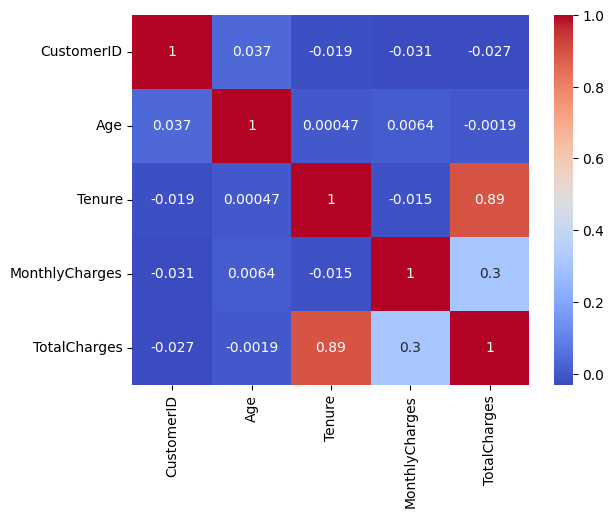

In [ ]:
sns.heatmap(numeric_column_datatypes.corr(), annot=True, cmap="coolwarm")

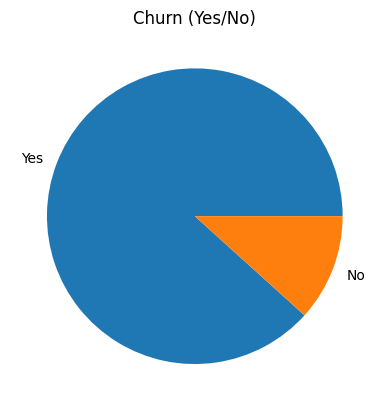

In [81]:
df['Churn'].value_counts().plot(kind="pie")
plt.title("Churn (Yes/No)")
plt.ylabel("")
plt.show()

In [82]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [83]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

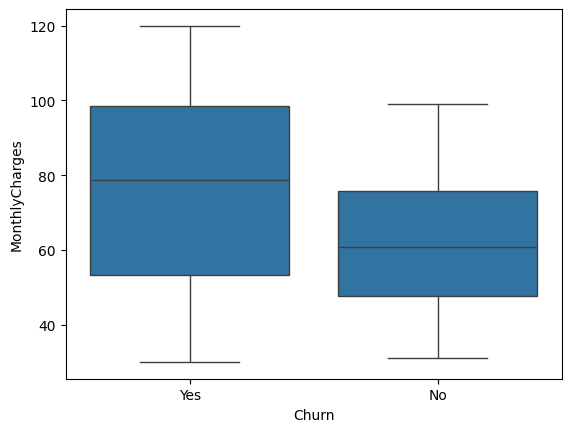

In [148]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)


In [84]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

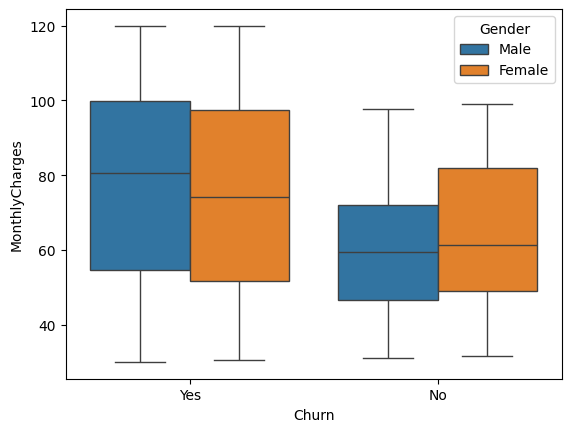

In [149]:
sns.boxplot(x="Churn", y="MonthlyCharges", hue="Gender", data=df)


In [85]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

<Axes: xlabel='Churn', ylabel='Tenure'>

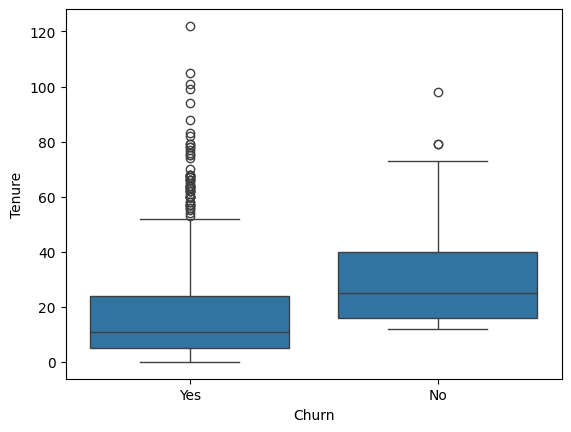

In [150]:
sns.boxplot(x="Churn", y="Tenure", data=df)


In [86]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

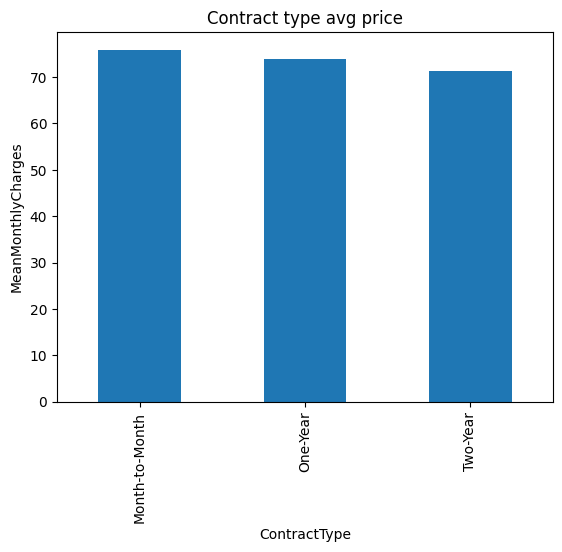

In [87]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.ylabel("MeanMonthlyCharges")
plt.xlabel("ContractType")
plt.title("Contract type avg price")
plt.show()

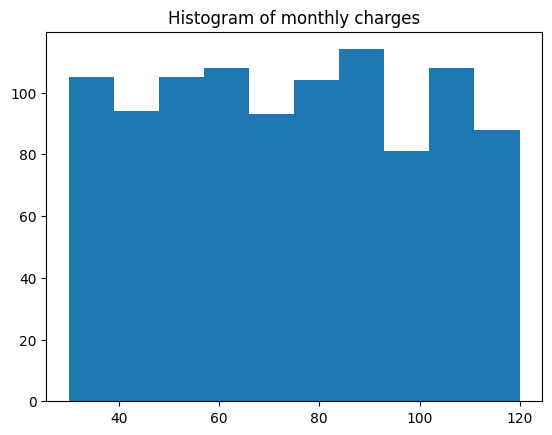

In [88]:
plt.hist(df['MonthlyCharges'])
plt.title("Histogram of monthly charges")
plt.show()

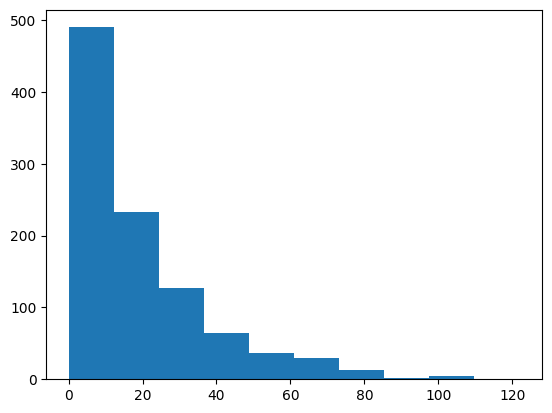

In [89]:
plt.hist(df['Tenure'])
plt.show()

In [90]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [91]:
y=df[["Churn"]]
X=df[["Age","Gender","Tenure","MonthlyCharges"]]

In [92]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [93]:
y

,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
995,Yes
996,Yes
997,Yes
998,Yes


In [94]:
X['Gender']=X['Gender'].apply(lambda x: 1 if x=="Female" else 0)

In [95]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [96]:
type(X['Gender'][0])

numpy.int64

In [97]:
y['Churn']=y['Churn'].apply(lambda x:1 if x=="Yes" else 0)

In [98]:
y.value_counts()

Churn
1        883
0        117
Name: count, dtype: int64

Modelling

In [99]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [100]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [101]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [102]:
import joblib
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [103]:
X_test=scaler.fit_transform(X_test)

In [104]:
X_train.shape

(800, 4)

In [105]:
X_test.shape

(200, 4)

In [106]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(y_test,predictions)))

In [107]:
from sklearn.model_selection import GridSearchCV

In [108]:
from sklearn.linear_model import LogisticRegression

In [109]:
import warnings
warnings.filterwarnings("ignore")

In [152]:
log = LogisticRegression(class_weight='balanced')
log.fit(X_train,y_train)

LogisticRegression(class_weight='balanced')

In [153]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [154]:
log.predict(X_test)

array([0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1])

In [155]:
y_pred=log.predict(X_test)

In [156]:
modelperformance(y_pred)

Accuracy score on model is 0.72


In [115]:
from sklearn.neighbors import KNeighborsClassifier

In [116]:
param_grid={
    "n_neighbors": [3,5,7,9],
    "weights":["uniform","distance"],
}

In [117]:
GridKN=GridSearchCV(KNeighborsClassifier(),param_grid,cv=5)

In [118]:
GridKN.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [119]:
GridKN.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [120]:
y_pred1=GridKN.predict(X_test)

In [121]:
modelperformance(y_pred1)

Accuracy score on model is 0.855


In [157]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Logistic Regression Report:\n", classification_report(y_test, y_pred))
print("KNN Report:\n", classification_report(y_test, y_pred1))

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_pred))
print("KNN ROC-AUC:", roc_auc_score(y_test, y_pred1))


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.28      0.76      0.40        25
           1       0.95      0.71      0.82       175

    accuracy                           0.72       200
   macro avg       0.61      0.74      0.61       200
weighted avg       0.87      0.72      0.77       200

KNN Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        25
           1       0.87      0.98      0.92       175

    accuracy                           0.85       200
   macro avg       0.44      0.49      0.46       200
weighted avg       0.76      0.85      0.81       200

Logistic Regression ROC-AUC: 0.7371428571428572
KNN ROC-AUC: 0.48857142857142855


In [159]:
from sklearn.ensemble import RandomForestClassifier
RFC=RandomForestClassifier(class_weight='balanced')

In [160]:
param_grid={
    "n_estimators" : [32,64,128,256],
    "max_features" : [2,3,4],
    "bootstrap" : [True,False]
}

In [161]:
grid_rfc=GridSearchCV(RFC,param_grid,cv=5)

In [162]:
grid_rfc.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(class_weight='balanced'),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 128, 256]})

In [163]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 256}

In [164]:
y_pred4=grid_rfc.predict(X_test)

In [165]:
modelperformance(y_pred4)

Accuracy score on model is 0.85


In [166]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred4 = grid_rfc.predict(X_test)
print(classification_report(y_test, y_pred4))
print("ROC-AUC:", roc_auc_score(y_test, y_pred4))


              precision    recall  f1-score   support

           0       0.22      0.08      0.12        25
           1       0.88      0.96      0.92       175

    accuracy                           0.85       200
   macro avg       0.55      0.52      0.52       200
weighted avg       0.80      0.85      0.82       200

ROC-AUC: 0.5199999999999999


In [129]:
from sklearn.svm import SVC
svm=SVC()

In [130]:
param_grid={
    "C": [0.01,0.1,0.5,1],
    "kernel":["Linear","rbf","poly"]
}

In [131]:
gridsvc= GridSearchCV(svm,param_grid,cv=5)

In [132]:
gridsvc.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'kernel': ['Linear', 'rbf', 'poly']})

In [133]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'rbf'}

In [134]:
y_pred2=gridsvc.predict(X_test)

In [135]:
modelperformance(y_pred2)

Accuracy score on model is 0.875


In [167]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred2 = gridsvc.predict(X_test)
print(classification_report(y_test, y_pred2))
print("ROC-AUC:", roc_auc_score(y_test, y_pred2))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        25
           1       0.88      1.00      0.93       175

    accuracy                           0.88       200
   macro avg       0.44      0.50      0.47       200
weighted avg       0.77      0.88      0.82       200

ROC-AUC: 0.5


In [136]:
from sklearn.tree import DecisionTreeClassifier

In [137]:
param_grid={
    "criterion" :["gini", "entropy"],
    "splitter" :["best","random"],
    "max_depth": [None,10,20,30],
    "min_samples_leaf" : [1,2,4],
    "min_samples_split" : [2,5,10]
}

In [138]:
grid_tree=GridSearchCV(DecisionTreeClassifier(),param_grid,cv=5)

In [139]:
grid_tree.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [140]:
grid_tree.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'splitter': 'random'}

In [141]:
y_pred3=grid_tree.predict(X_test)

In [142]:
y_pred3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [143]:
modelperformance(y_pred3)

Accuracy score on model is 0.87


In [168]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred3 = grid_tree.predict(X_test)
print(classification_report(y_test, y_pred3))
print("ROC-AUC:", roc_auc_score(y_test, y_pred3))


              precision    recall  f1-score   support

           0       0.46      0.24      0.32        25
           1       0.90      0.96      0.93       175

    accuracy                           0.87       200
   macro avg       0.68      0.60      0.62       200
weighted avg       0.84      0.87      0.85       200

ROC-AUC: 0.6


In [144]:
best_model=grid_tree.best_estimator_

In [146]:
X.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges'], dtype='object')

In [145]:
joblib.dump(best_model,"model.pkl")

['model.pkl']